# Prueba rápida: workflow EdgeCompat DXY

Este notebook valida el flujo completo con una fracción pequeña de datos reales: construcción del cache TPS con `GenMuon_dXY`, entrenamiento corto del modelo con conectividad estructurada y evaluación. No es un benchmark de física ni mide métricas representativas de producción.

Selecciona el kernel `venv/bin/python` del proyecto antes de ejecutar. La configuración usa un ROOT por muestra de `C1` (prompt), `C10` (desplazado) y `B4` (sin señal), y dos épocas. Los artefactos quedan aislados en `build/omtf_gmt/notebook_edge_dxy_smoke/`.

## Flujo
1. Comprobar entorno, dependencias y dispositivo.
2. Definir rutas, semillas y tamaños reducidos.
3. Localizar ROOT de prueba y construir un cache mini.
4. Validar el manifest, tensores, valores y etiquetas.
5. Revisar el split 85/15 reproducible que usa el trainer.
6. Entrenar `edge_compat_dxy` brevemente.
7. Evaluar y mostrar métricas e informe.
8. Guardar checkpoint y reportes.
9. Recargar el checkpoint y ejecutar inferencia.
10. Ejecutar asserts del flujo completo.

Ejecuta las celdas en orden. Si un ROOT no contiene `GenMuon_dXY`, el builder fallará intencionalmente con `--require-dxy`.

## 1–2. Entorno y parámetros
La celda siguiente importa PyTorch, NumPy y Uproot, localiza el repositorio y fija rutas, semilla, datasets, tamaño de muestra, épocas, batch y dispositivo. El smoke test usa cinco pares ROOT por dataset para ampliar el entrenamiento sin leer la producción completa. Usa el kernel `venv`; corre en CPU por defecto. Si falta alguna dependencia, instala `venv/bin/pip install -r requirements.txt`; si VS Code no ofrece el `venv` como kernel, instala `venv/bin/python -m pip install ipykernel`.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import platform

import numpy as np
import torch
import uproot

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src/omtf_gmt/train.py").is_file()
     and (path / "scripts/make_dataset.py").is_file()),
    None,
)
assert ROOT is not None, "Abre el notebook desde el workspace del repositorio."
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

DATASETS = [
    "C1_prompt_pt2to5_overlap",
    "C10_disp_pt20to50_overlap",
    "B4",
]
MAX_FILES = 5
EPOCHS = 2
HIDDEN = 16
BATCH_SIZE = 128
SEED = 42
ML_DXY_THRESHOLD_CM = 2.0
DEVICE = os.environ.get("OMTF_DEVICE", "cpu")
assert DEVICE == "cpu" or (DEVICE == "cuda" and torch.cuda.is_available())
RUN_DIR = ROOT / "build/omtf_gmt/notebook_edge_dxy_smoke"
CACHE_DIR = RUN_DIR / "cache"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
CHECKPOINT = CHECKPOINT_DIR / "gmt_edge_compat_dxy_best.pt"
EVAL_REPORT = RUN_DIR / "quick_eval.md"

RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Repositorio: {ROOT}")
print(f"Python {platform.python_version()} | torch {torch.__version__} | uproot {uproot.__version__}")
print(f"Dispositivo: {DEVICE} | CUDA disponible: {torch.cuda.is_available()}")
print(f"Datasets: {DATASETS} | pares ROOT/dataset: {MAX_FILES} | epochs: {EPOCHS}")
print(f"Outputs: {RUN_DIR}")

Repositorio: /lhome/ext/uovi156/uovi1561/omtf_gnn_study
Python 3.9.25 | torch 2.8.0+cu128 | uproot 5.6.9
Dispositivo: cpu | CUDA disponible: True
Datasets: ['C1_prompt_pt2to5_overlap', 'C10_disp_pt20to50_overlap', 'B4'] | pares ROOT/dataset: 5 | epochs: 2
Outputs: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke


## 3. Cargar datos pequeños
Se usa el primer par `omtf_hits`/`omtf_nano` disponible de cada muestra. El builder limita la lectura a `MAX_FILES` y genera stubs TPS, etiquetas y targets de dxy.

In [2]:
ROOT_PAIRS = {}
for dataset in DATASETS:
    folder = ROOT / "data/prod" / dataset
    hits = {p.stem.removeprefix("omtf_hits_"): p for p in folder.glob("omtf_hits_*.root")}
    nanos = {p.stem.removeprefix("omtf_nano_"): p for p in folder.glob("omtf_nano_*.root")}
    assert hits and nanos, f"No encontré pares ROOT para {dataset}: {folder}"
    common = sorted(hits.keys() & nanos.keys())
    assert len(common) == len(hits) == len(set(hits))
    chosen = common[:MAX_FILES]
    assert len(chosen) == MAX_FILES, f"{dataset} tiene menos de {MAX_FILES} pares"
    with uproot.open(nanos[chosen[0]]) as root_file:
        assert "GenMuon_dXY" in root_file["Events"].keys(), f"Falta GenMuon_dXY en {nanos[chosen[0]]}"
    ROOT_PAIRS[dataset] = [(hits[key], nanos[key]) for key in chosen]
    print(f"{dataset}: {len(common)} pares disponibles; usaré {chosen}")

C1_prompt_pt2to5_overlap: 400 pares disponibles; usaré ['C1_prompt_pt2to5_overlap_0', 'C1_prompt_pt2to5_overlap_1', 'C1_prompt_pt2to5_overlap_10', 'C1_prompt_pt2to5_overlap_100', 'C1_prompt_pt2to5_overlap_101']
C10_disp_pt20to50_overlap: 300 pares disponibles; usaré ['C10_disp_pt20to50_overlap_3050', 'C10_disp_pt20to50_overlap_3051', 'C10_disp_pt20to50_overlap_3052', 'C10_disp_pt20to50_overlap_3053', 'C10_disp_pt20to50_overlap_3054']
B4: 366 pares disponibles; usaré ['B4_0', 'B4_1', 'B4_10', 'B4_100', 'B4_101']


## 4. Validar y construir el cache
El cache se escribe en una ruta dedicada. `--require-dxy` hace fallar el builder si falta el target de impacto transverso en algún NanoAOD seleccionado.

In [3]:
build_cmd = [
    sys.executable, str(ROOT / "scripts/make_dataset.py"),
    "--data-dir", str(ROOT / "data/prod"),
    "--output-dir", str(CACHE_DIR),
    "--datasets", *DATASETS,
    "--max-files", str(MAX_FILES),
    "--require-dxy",
]
print(" ".join(build_cmd))
subprocess.run(build_cmd, cwd=ROOT, check=True)

manifest = json.loads((CACHE_DIR / "manifest.json").read_text())
assert manifest["schema_version"] == 2
for dataset in DATASETS:
    info = manifest["datasets"][dataset]
    assert info["gen_dxy_required"] is True
    assert info["n_samples"] > 0
    print(f"{dataset}: {info['n_samples']} samples, {info['n_shards']} shard(s), dxy requerido")

/lhome/ext/uovi156/uovi1561/omtf_gnn_study/venv/bin/python /lhome/ext/uovi156/uovi1561/omtf_gnn_study/scripts/make_dataset.py --data-dir /lhome/ext/uovi156/uovi1561/omtf_gnn_study/data/prod --output-dir /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/cache --datasets C1_prompt_pt2to5_overlap C10_disp_pt20to50_overlap B4 --max-files 5 --require-dxy


  [C1_prompt_pt2to5_overlap] 5/5 files  samples_so_far=199
  [C1_prompt_pt2to5_overlap] done — 199 samples in 3s
  [C10_disp_pt20to50_overlap] 5/5 files  samples_so_far=503
  [C10_disp_pt20to50_overlap] done — 503 samples in 3s
  [B4] 5/5 files  samples_so_far=2,355
  [B4] done — 2,355 samples in 10s

Manifest written to /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/cache/manifest.json
C1_prompt_pt2to5_overlap: 199 samples, 1 shard(s), dxy requerido
C10_disp_pt20to50_overlap: 503 samples, 1 shard(s), dxy requerido
B4: 2355 samples, 1 shard(s), dxy requerido


## 5. Esquema, calidad y split
El builder ya normaliza las features TPS. Comprobamos dimensiones, finitud, padding, targets y duplicados por `(event, processor)`. Luego reproducimos el split 85/15 con semilla 42 que usa el trainer; este split es una inspección, el script de entrenamiento crea el suyo.

In [4]:
from omtf_gmt.dataset import GMTCachedDataset

cached = {}
split_summary = {}
for name in DATASETS:
    dataset = GMTCachedDataset(CACHE_DIR, name)
    cached[name] = dataset
    assert dataset.stubs.ndim == 3 and dataset.stubs.shape[1:] == (24, 14)
    assert dataset.valid_mask.dtype == torch.bool
    assert dataset.gen_pt.shape == dataset.gen_dxy.shape == (len(dataset), 3)
    assert torch.isfinite(dataset.stubs).all()
    assert torch.isfinite(dataset.gen_pt).all() and torch.isfinite(dataset.gen_dxy).all()
    assert torch.all(dataset.gen_pt >= 0)
    assert torch.all(dataset.node_label[~dataset.valid_mask] == 0)
    assert torch.all(dataset.stubs[~dataset.valid_mask] == 0)

    sample_keys = list(zip(dataset.meta_event.tolist(), dataset.meta_proc.tolist()))
    repeated_keys = len(sample_keys) - len(set(sample_keys))
    n_train = int(0.85 * len(dataset))
    n_val = len(dataset) - n_train
    train_part, val_part = torch.utils.data.random_split(
        dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED)
    )
    split_summary[name] = (len(train_part), len(val_part))
    print(
        f"{name}: n={len(dataset)}, stubs={tuple(dataset.stubs.shape)}, "
        f"train/val={len(train_part)}/{len(val_part)}, "
        f"signal slots={(dataset.gen_pt > 0).sum().item()}, "
        f"repeated event/proc keys={repeated_keys} (reported only; run/lumi are not in cache metadata)"
    )

assert all(val_size > 0 for _, val_size in split_summary.values())

C1_prompt_pt2to5_overlap: n=199, stubs=(199, 24, 14), train/val=169/30, signal slots=196, repeated event/proc keys=11 (reported only; run/lumi are not in cache metadata)
C10_disp_pt20to50_overlap: n=503, stubs=(503, 24, 14), train/val=427/76, signal slots=494, repeated event/proc keys=71 (reported only; run/lumi are not in cache metadata)
B4: n=2355, stubs=(2355, 24, 14), train/val=2001/354, signal slots=0, repeated event/proc keys=1925 (reported only; run/lumi are not in cache metadata)


## 6. Distribuciones de inputs: nodos y aristas
Antes de entrenar, inspeccionamos las features TPS de nodos válidos y los atributos geométricos/topológicos de las aristas que realmente admite la máscara estructurada. C10 desplazado es la señal; C1 prompt y B4 son fondos/controles para el estudio de desplazamiento. Cada arista no dirigida se cuenta una vez.

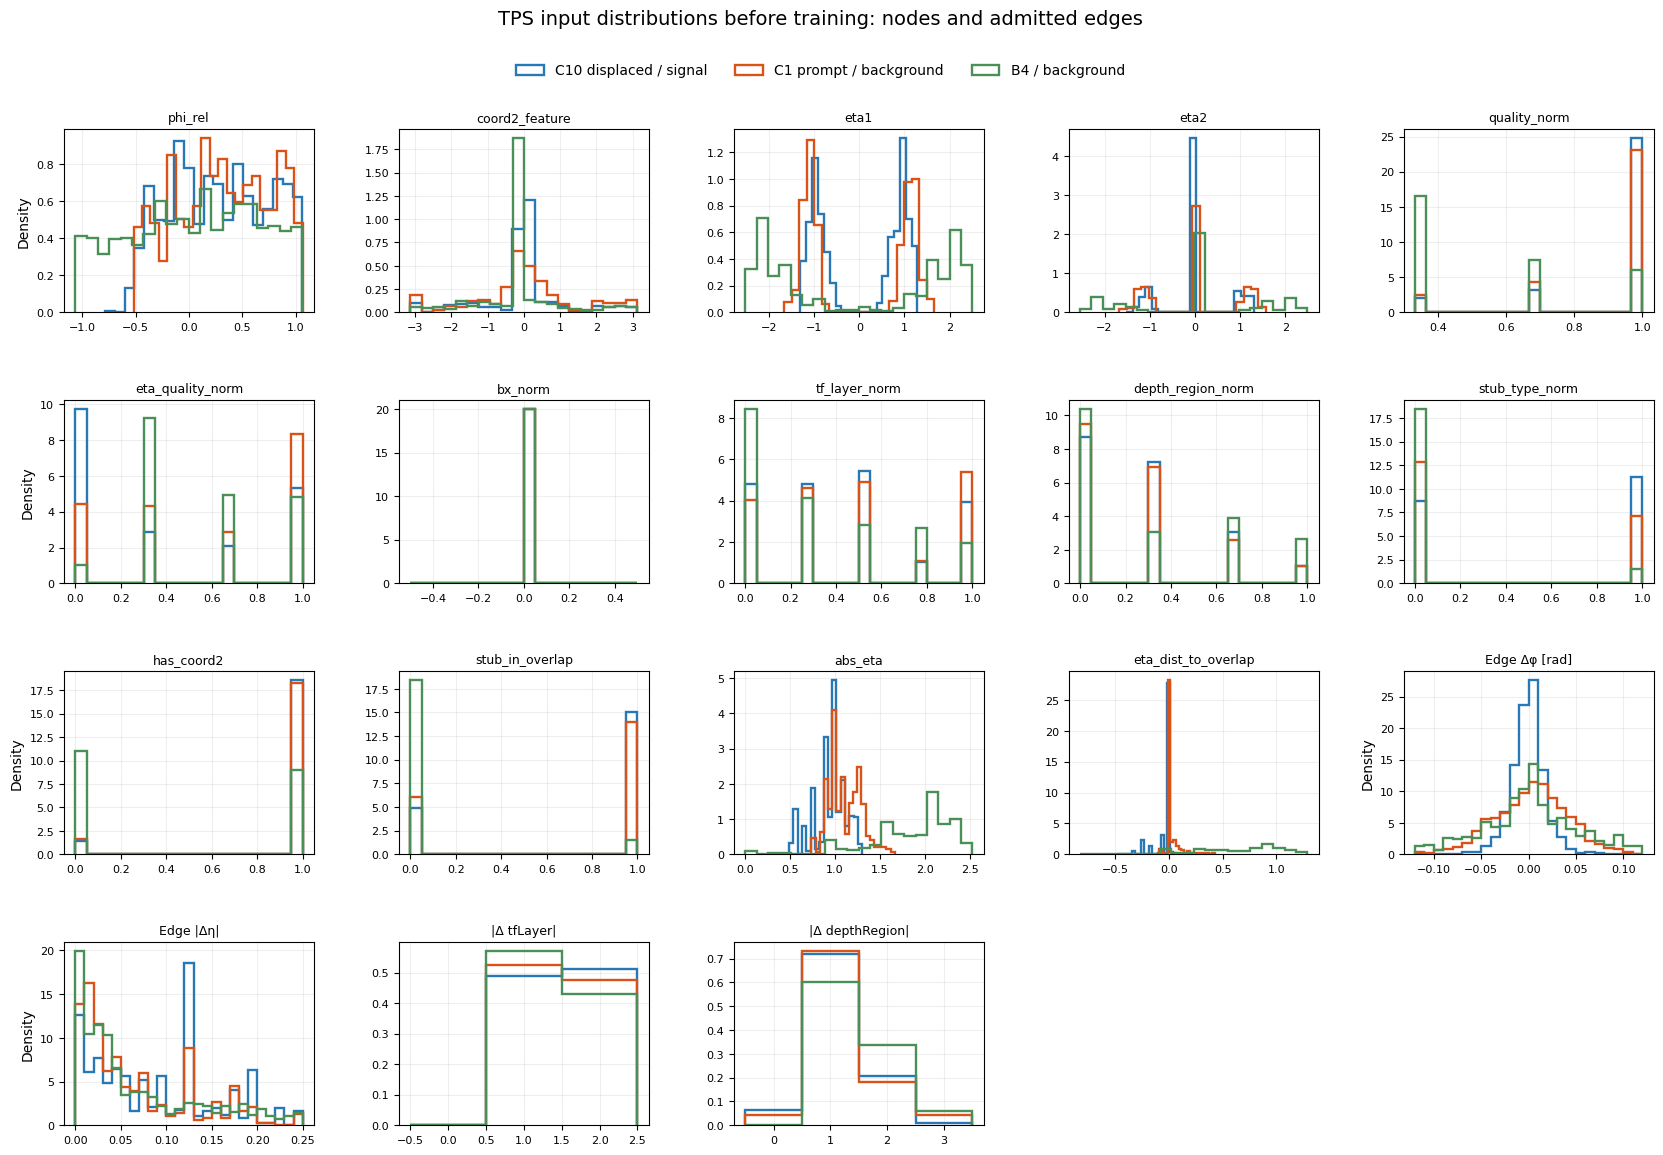

C10 displaced / signal: 1,709 valid nodes; 1,688 unique admitted edges
C1 prompt / background: 548 valid nodes; 485 unique admitted edges
B4 / background: 8,635 valid nodes; 4,815 unique admitted edges
Saved plot: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/input_node_edge_distributions.png


In [5]:
import matplotlib.pyplot as plt
from omtf_gmt.features_tps import FEATURE_NAMES_TPS
from omtf_gmt.models.edge_compat_dxy import _structured_edge_mask

INPUT_PLOT_DATASETS = {
    "C10_disp_pt20to50_overlap": "C10 displaced / signal",
    "C1_prompt_pt2to5_overlap": "C1 prompt / background",
    "B4": "B4 / background",
}
NODE_FEATURES = {name: [] for name in INPUT_PLOT_DATASETS}
EDGE_FEATURES = {
    name: {"delta_phi": [], "abs_delta_eta": [], "layer_gap": [], "station_gap": []}
    for name in INPUT_PLOT_DATASETS
}

for name in INPUT_PLOT_DATASETS:
    dataset = cached[name]
    for start in range(0, len(dataset), BATCH_SIZE):
        stop = min(start + BATCH_SIZE, len(dataset))
        stubs_batch = dataset.stubs[start:stop]
        valid_batch = dataset.valid_mask[start:stop]
        node_values = stubs_batch[valid_batch].numpy()
        NODE_FEATURES[name].append(node_values)

        edge_mask = _structured_edge_mask(stubs_batch, valid_batch)
        unique_edges = torch.triu(edge_mask, diagonal=1)
        batch_indices, source_indices, target_indices = torch.where(unique_edges)
        if len(batch_indices) == 0:
            continue

        source = stubs_batch[batch_indices, source_indices]
        target = stubs_batch[batch_indices, target_indices]
        delta_phi = source[:, 0] - target[:, 0]
        delta_phi = torch.remainder(delta_phi + torch.pi, 2 * torch.pi) - torch.pi
        delta_eta = source[:, 2] - target[:, 2]
        layer = (stubs_batch[..., 7] * 4).round()
        station = (stubs_batch[..., 8] * 3 + 1).round()
        layer_gap = (layer[batch_indices, source_indices] - layer[batch_indices, target_indices]).abs()
        station_gap = (station[batch_indices, source_indices] - station[batch_indices, target_indices]).abs()

        EDGE_FEATURES[name]["delta_phi"].append(delta_phi.numpy())
        EDGE_FEATURES[name]["abs_delta_eta"].append(delta_eta.abs().numpy())
        EDGE_FEATURES[name]["layer_gap"].append(layer_gap.numpy())
        EDGE_FEATURES[name]["station_gap"].append(station_gap.numpy())

for name in INPUT_PLOT_DATASETS:
    NODE_FEATURES[name] = np.concatenate(NODE_FEATURES[name])
    for edge_name, chunks in EDGE_FEATURES[name].items():
        EDGE_FEATURES[name][edge_name] = np.concatenate(chunks) if chunks else np.array([])

fig, axes = plt.subplots(4, 5, figsize=(17, 12), constrained_layout=False)
node_axes = axes.flat[:len(FEATURE_NAMES_TPS)]
node_colors = {
    "C10_disp_pt20to50_overlap": "#2878B5",
    "C1_prompt_pt2to5_overlap": "#D95319",
    "B4": "#4A8F55",
}
for feature_index, (ax, feature_name) in enumerate(zip(node_axes, FEATURE_NAMES_TPS)):
    for name, label in INPUT_PLOT_DATASETS.items():
        values = NODE_FEATURES[name][:, feature_index]
        ax.hist(values, bins=20, density=True, histtype="step", linewidth=1.7,
                color=node_colors[name], label=label)
    ax.set_title(feature_name, fontsize=9)
    ax.grid(alpha=0.2)
    if feature_index % 5 == 0:
        ax.set_ylabel("Density")

edge_specs = [
    ("delta_phi", "Edge Δφ [rad]", np.linspace(-0.12, 0.12, 25)),
    ("abs_delta_eta", "Edge |Δη|", np.linspace(0.0, 0.25, 26)),
    ("layer_gap", "|Δ tfLayer|", np.arange(-0.5, 3.5, 1.0)),
    ("station_gap", "|Δ depthRegion|", np.arange(-0.5, 4.5, 1.0)),
]
for ax, (feature_name, title, bins) in zip(axes.flat[len(FEATURE_NAMES_TPS):], edge_specs):
    for name, label in INPUT_PLOT_DATASETS.items():
        values = EDGE_FEATURES[name][feature_name]
        if values.size:
            ax.hist(values, bins=bins, density=True, histtype="step", linewidth=1.7,
                    color=node_colors[name], label=label)
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.2)
    if title in ("Edge Δφ [rad]", "Edge |Δη|"):
        ax.set_ylabel("Density")

for ax in axes.flat:
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(FEATURE_NAMES_TPS) + len(edge_specs):]:
    ax.set_visible(False)

fig.subplots_adjust(left=0.055, right=0.99, bottom=0.06, top=0.89,
                    wspace=0.34, hspace=0.48)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=3, frameon=False)
fig.suptitle("TPS input distributions before training: nodes and admitted edges",
             fontsize=14, y=0.99)
INPUT_DISTRIBUTIONS_PATH = RUN_DIR / "input_node_edge_distributions.png"
fig.savefig(INPUT_DISTRIBUTIONS_PATH, dpi=150)
plt.show()

for name, label in INPUT_PLOT_DATASETS.items():
    edge_count = len(EDGE_FEATURES[name]["delta_phi"])
    print(f"{label}: {len(NODE_FEATURES[name]):,} valid nodes; {edge_count:,} unique admitted edges")
print(f"Saved plot: {INPUT_DISTRIBUTIONS_PATH}")

Pairs passing topology=3,598, geometry=4,348, both=3,376; maximum edges in one window=14


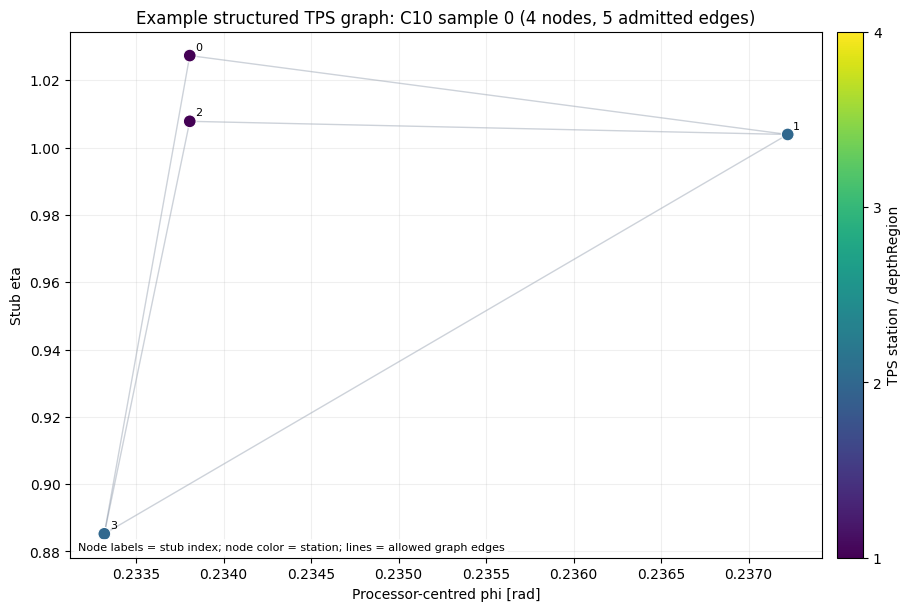

Example graph: event=1, processor=0, signal slots=[0], edges=5; saved to /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/example_tps_graph.png


In [6]:
import importlib
import omtf_gmt.models.edge_compat_dxy as edge_compat_dxy_module
edge_compat_dxy_module = importlib.reload(edge_compat_dxy_module)
_structured_edge_mask = edge_compat_dxy_module._structured_edge_mask

from omtf_gmt.features_tps import (
    F_TPS_DEPTH_REGION,
    F_TPS_ETA1,
    F_TPS_PHI_REL,
    F_TPS_TF_LAYER,
 )

graph_dataset = cached["C10_disp_pt20to50_overlap"]
sample_index = None
best_sample_index = None
best_edge_count = 0
topology_pair_count = 0
geometry_pair_count = 0
joint_pair_count = 0
for start in range(0, len(graph_dataset), BATCH_SIZE):
    stop = min(start + BATCH_SIZE, len(graph_dataset))
    stubs_batch = graph_dataset.stubs[start:stop]
    valid_batch = graph_dataset.valid_mask[start:stop]
    phi_batch = stubs_batch[..., F_TPS_PHI_REL]
    eta_batch = stubs_batch[..., F_TPS_ETA1]
    layer_batch = (stubs_batch[..., F_TPS_TF_LAYER] * 4).round()
    station_batch = (stubs_batch[..., F_TPS_DEPTH_REGION] * 3 + 1).round()
    delta_phi = phi_batch.unsqueeze(2) - phi_batch.unsqueeze(1)
    delta_phi = torch.remainder(delta_phi + torch.pi, 2 * torch.pi) - torch.pi
    delta_eta = eta_batch.unsqueeze(2) - eta_batch.unsqueeze(1)
    layer_gap = (layer_batch.unsqueeze(2) - layer_batch.unsqueeze(1)).abs()
    station_gap = (station_batch.unsqueeze(2) - station_batch.unsqueeze(1)).abs()
    topology = (((layer_gap >= 1) & (layer_gap <= 2)) | ((station_gap >= 1) & (station_gap <= 2)))
    geometry = (delta_phi.abs() <= 0.12) & (delta_eta.abs() <= 0.25)
    pair_valid = valid_batch.unsqueeze(2) & valid_batch.unsqueeze(1)
    no_self = ~torch.eye(stubs_batch.shape[1], dtype=torch.bool).unsqueeze(0)
    topology_pair_count += int((pair_valid & no_self & topology).sum())
    geometry_pair_count += int((pair_valid & no_self & geometry).sum())
    joint_pair_count += int((pair_valid & no_self & topology & geometry).sum())
    edge_mask = torch.triu(_structured_edge_mask(stubs_batch, valid_batch), diagonal=1)
    edge_counts = edge_mask.sum(dim=(1, 2))
    local_best_count, local_best = edge_counts.max(dim=0)
    if int(local_best_count) > best_edge_count:
        best_edge_count = int(local_best_count)
        best_sample_index = start + int(local_best)
    occupied = (graph_dataset.gen_pt[start:stop] > 0).any(dim=1)
    with_edges = torch.where(occupied & (edge_counts > 0))[0]
    if sample_index is None and len(with_edges):
        sample_index = start + int(with_edges[0])

print(
    f"Pairs passing topology={topology_pair_count:,}, geometry={geometry_pair_count:,}, "
    f"both={joint_pair_count:,}; maximum edges in one window={best_edge_count}"
 )
if sample_index is None:
    sample_index = best_sample_index
assert sample_index is not None and best_edge_count > 0, "El cache no contiene ninguna arista admitida por la máscara TPS."
sample_stubs = graph_dataset.stubs[sample_index]
sample_valid = graph_dataset.valid_mask[sample_index]
sample_edge_mask = torch.triu(
    _structured_edge_mask(sample_stubs.unsqueeze(0), sample_valid.unsqueeze(0))[0],
    diagonal=1,
 )
edge_sources, edge_targets = torch.where(sample_edge_mask)
node_indices = torch.where(sample_valid)[0]
phi = sample_stubs[:, F_TPS_PHI_REL]
eta = sample_stubs[:, F_TPS_ETA1]
layer = (sample_stubs[:, F_TPS_TF_LAYER] * 4).round().to(torch.int64)
station = (sample_stubs[:, F_TPS_DEPTH_REGION] * 3 + 1).round().to(torch.int64)

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
for source, target in zip(edge_sources.tolist(), edge_targets.tolist()):
    ax.plot(
        [phi[source], phi[target]], [eta[source], eta[target]],
        color="#64748B", alpha=0.32, linewidth=1.0, zorder=1,
    )
points = ax.scatter(
    phi[node_indices], eta[node_indices],
    c=station[node_indices], cmap="viridis", vmin=1, vmax=4,
    s=85, edgecolors="white", linewidths=0.8, zorder=2,
 )
for node_index in node_indices.tolist():
    ax.annotate(
        str(node_index), (phi[node_index], eta[node_index]),
        xytext=(4, 4), textcoords="offset points", fontsize=8, zorder=3,
    )
colorbar = fig.colorbar(points, ax=ax, ticks=[1, 2, 3, 4], pad=0.02)
colorbar.set_label("TPS station / depthRegion")
ax.set(
    xlabel="Processor-centred phi [rad]", ylabel="Stub eta",
    title=(
        f"Example structured TPS graph: C10 sample {sample_index} "
        f"({len(node_indices)} nodes, {len(edge_sources)} admitted edges)"
    ),
 )
ax.grid(alpha=0.2)
ax.text(
    0.01, 0.01, "Node labels = stub index; node color = station; lines = allowed graph edges",
    transform=ax.transAxes, fontsize=8, va="bottom",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
 )
EXAMPLE_GRAPH_PATH = RUN_DIR / "example_tps_graph.png"
fig.savefig(EXAMPLE_GRAPH_PATH, dpi=160)
plt.show()
print(
    f"Example graph: event={int(graph_dataset.meta_event[sample_index])}, "
    f"processor={int(graph_dataset.meta_proc[sample_index])}, "
    f"signal slots={(graph_dataset.gen_pt[sample_index] > 0).nonzero().flatten().tolist()}, "
    f"edges={len(edge_sources)}; saved to {EXAMPLE_GRAPH_PATH}"
 )

### Ejemplo de grafo TPS
La figura muestra una ventana C10 real: los nodos son stubs, el color indica `depthRegion` y las líneas son las aristas estructurales admitidas (topología y proximidad en φ/η). La búsqueda elige una ventana con señal y conectividad; el resumen cuenta parejas candidatas en todo el cache.

## 6. Entrenar el modelo
El trainer guarda el mejor checkpoint según su loss de validación. Para acelerar esta prueba usamos hidden=16, dos épocas, batch pequeño y cero workers. La cabeza `dxy` usa un contexto por slot; `--w-assign 0.1` supervisa su atención con `track_id`.

In [7]:
train_cmd = [
    sys.executable, str(ROOT / "src/omtf_gmt/train.py"),
    "--cache-dir", str(CACHE_DIR),
    "--datasets", *DATASETS,
    "--repeat", "B4:1",
    "--model", "edge_compat_dxy",
    "--hidden", str(HIDDEN),
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--num-workers", "0",
    "--w-dxy", "1.0",
    "--w-assign", "0.1",
    "--output-dir", str(CHECKPOINT_DIR),
    "--device", DEVICE,
]
print(" ".join(train_cmd))
subprocess.run(train_cmd, cwd=ROOT, check=True)
assert CHECKPOINT.is_file(), f"No se creó el checkpoint: {CHECKPOINT}"
print(f"Checkpoint generado: {CHECKPOINT}")

/lhome/ext/uovi156/uovi1561/omtf_gnn_study/venv/bin/python /lhome/ext/uovi156/uovi1561/omtf_gnn_study/src/omtf_gmt/train.py --cache-dir /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/cache --datasets C1_prompt_pt2to5_overlap C10_disp_pt20to50_overlap B4 --repeat B4:1 --model edge_compat_dxy --hidden 16 --epochs 2 --batch-size 128 --num-workers 0 --w-dxy 1.0 --w-assign 0.1 --output-dir /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/checkpoints --device cpu
Effective training mix (WeightedRandomSampler):
  C1_prompt_pt2to5_overlap: 169 (6.5%)
  C10_disp_pt20to50_overlap: 427 (16.4%)
  B4: 2,001 (77.1%)
  Total train: 2,597  |  Val: 460  |  Device: cpu
Model: edge_compat_dxy  params=2,843


/lhome/ext/uovi156/uovi1561/omtf_gnn_study/src/omtf_gmt/train.py:532: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=args.amp)
/lhome/ext/uovi156/uovi1561/omtf_gnn_study/src/omtf_gmt/train.py:557: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=args.amp):
/lhome/ext/uovi156/uovi1561/omtf_gnn_study/src/omtf_gmt/train.py:590: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=args.amp):


[  1/2] tr=23.6396  val=6.5235  recall=0.000  cand_rec=0.000  zero_fp=0.994  xslot_fp=0.363  (1s)
[  2/2] tr=22.2352  val=6.1227  recall=0.000  cand_rec=0.000  zero_fp=0.000  xslot_fp=0.000  (1s)

Best val_loss=6.1227 at checkpoint: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/checkpoints/gmt_edge_compat_dxy_best.pt
History: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/checkpoints/gmt_edge_compat_dxy_history.json
Checkpoint generado: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/checkpoints/gmt_edge_compat_dxy_best.pt


## Diagnóstico del output de la red
Tras entrenar, recargamos el mejor checkpoint y mostramos scores de nodo/candidato y regresiones pT/dxy en validación. Para la búsqueda de desplazados, C10 ocupado es señal; C1 prompt, slots vacíos y B4 son fondos/controles. C1 conserva su target físico de candidato ocupado y dxy≈0 durante el entrenamiento.

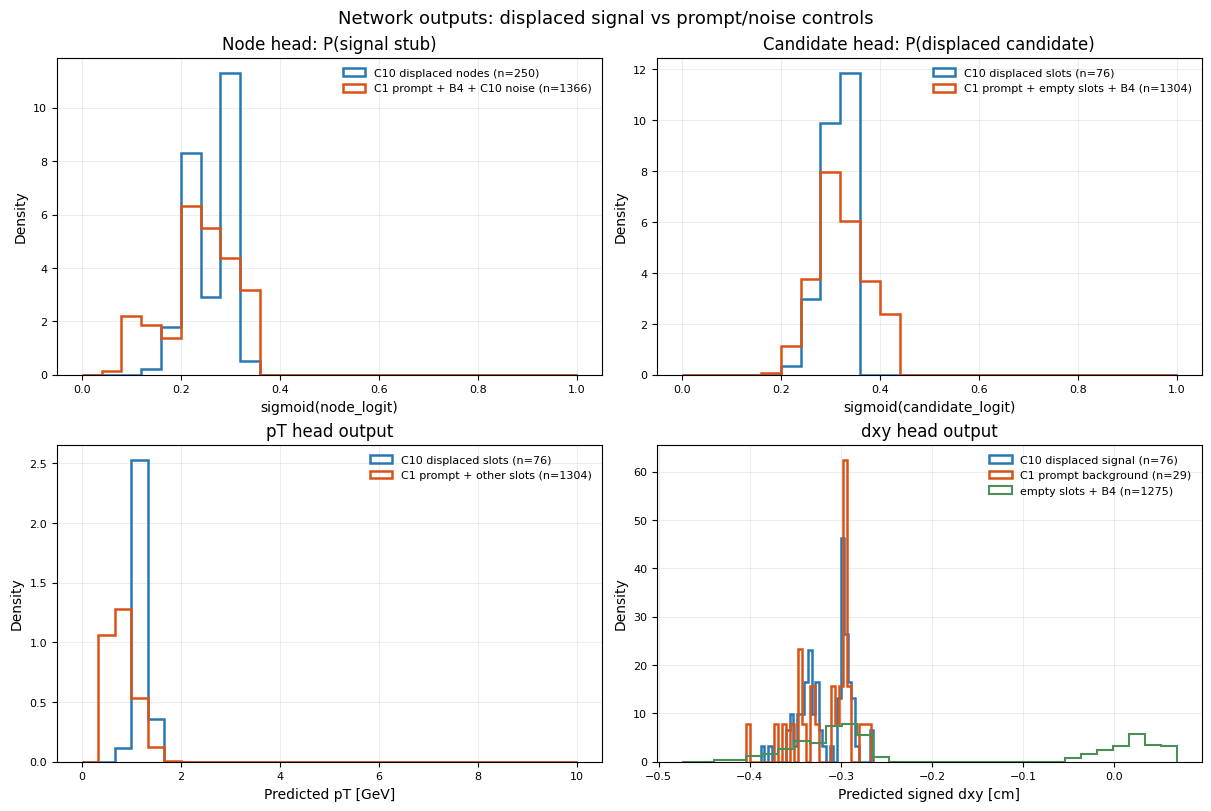

Saved plot: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/network_output_distributions.png
Counts: {'node_signal': 250, 'node_background': 1366, 'candidate_signal': 76, 'candidate_background': 1304, 'pt_signal': 76, 'pt_background': 1304, 'dxy_signal': 76, 'dxy_prompt_background': 29, 'dxy_other_background': 1275}


In [8]:
from omtf_gmt.models import build_edge_compat_dxy

output_payload = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
output_args = output_payload.get("args", {})
output_model = build_edge_compat_dxy(
    hidden=int(output_args.get("hidden", HIDDEN)),
    dropout=float(output_args.get("dropout", 0.0)),
)
output_model.load_state_dict(output_payload["model"])
output_model.to(DEVICE).eval()

OUTPUT_DATASETS = [
    "C1_prompt_pt2to5_overlap",
    "C10_disp_pt20to50_overlap",
    "B4",
]
output_values = {
    "node_signal": [],
    "node_background": [],
    "candidate_signal": [],
    "candidate_background": [],
    "pt_signal": [],
    "pt_background": [],
    "dxy_signal": [],
    "dxy_prompt_background": [],
    "dxy_other_background": [],
}
output_counts = {name: 0 for name in output_values}

with torch.no_grad():
    for name in OUTPUT_DATASETS:
        dataset = cached[name]
        n_train = int(0.85 * len(dataset))
        _, validation_subset = torch.utils.data.random_split(
            dataset,
            [n_train, len(dataset) - n_train],
            generator=torch.Generator().manual_seed(42),
        )
        validation_indices = list(validation_subset.indices)
        for start in range(0, len(validation_indices), BATCH_SIZE):
            batch_indices = validation_indices[start:start + BATCH_SIZE]
            stubs_batch = dataset.stubs[batch_indices].to(DEVICE)
            valid_batch = dataset.valid_mask[batch_indices].to(DEVICE)
            gen_pt_batch = dataset.gen_pt[batch_indices]
            network_output = output_model(stubs_batch, valid_batch)
            node_probability = torch.sigmoid(network_output["node_logit"]).cpu()
            candidate_probability = torch.sigmoid(network_output["candidate_logits"]).cpu()
            pt_prediction = network_output["pt_pred"].cpu()
            dxy_prediction = network_output["dxy_pred"].cpu()
            candidate_target = gen_pt_batch > 0
            node_target = dataset.node_label[batch_indices] > 0

            node_valid = dataset.valid_mask[batch_indices]
            if name == "C10_disp_pt20to50_overlap":
                node_signal_mask = node_target & node_valid
                node_background_mask = (~node_target) & node_valid
            else:
                node_signal_mask = torch.zeros_like(node_valid)
                node_background_mask = node_valid
            output_values["node_signal"].append(node_probability[node_signal_mask])
            output_values["node_background"].append(node_probability[node_background_mask])
            output_counts["node_signal"] += int(node_signal_mask.sum())
            output_counts["node_background"] += int(node_background_mask.sum())

            if name == "C10_disp_pt20to50_overlap":
                candidate_signal_mask = candidate_target
            else:
                candidate_signal_mask = torch.zeros_like(candidate_target)
            candidate_background_mask = ~candidate_signal_mask
            output_values["candidate_signal"].append(candidate_probability[candidate_signal_mask])
            output_values["candidate_background"].append(candidate_probability[candidate_background_mask])
            output_counts["candidate_signal"] += int(candidate_signal_mask.sum())
            output_counts["candidate_background"] += int(candidate_background_mask.sum())
            output_values["pt_signal"].append(pt_prediction[candidate_signal_mask])
            output_values["pt_background"].append(pt_prediction[~candidate_signal_mask])
            output_counts["pt_signal"] += int(candidate_signal_mask.sum())
            output_counts["pt_background"] += int((~candidate_signal_mask).sum())

            if name == "C10_disp_pt20to50_overlap":
                output_values["dxy_signal"].append(dxy_prediction[candidate_signal_mask])
                output_counts["dxy_signal"] += int(candidate_signal_mask.sum())
                output_values["dxy_other_background"].append(dxy_prediction[~candidate_signal_mask])
                output_counts["dxy_other_background"] += int((~candidate_signal_mask).sum())
            elif name == "C1_prompt_pt2to5_overlap":
                output_values["dxy_prompt_background"].append(dxy_prediction[candidate_target])
                output_counts["dxy_prompt_background"] += int(candidate_target.sum())
                output_values["dxy_other_background"].append(dxy_prediction[~candidate_target])
                output_counts["dxy_other_background"] += int((~candidate_target).sum())
            else:
                output_values["dxy_other_background"].append(dxy_prediction.reshape(-1))
                output_counts["dxy_other_background"] += dxy_prediction.numel()

for name, tensors in output_values.items():
    nonempty = [tensor.reshape(-1) for tensor in tensors if tensor.numel()]
    output_values[name] = torch.cat(nonempty).numpy() if nonempty else np.array([])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
score_bins = np.linspace(0.0, 1.0, 26)
axes[0, 0].hist(output_values["node_signal"], bins=score_bins, density=True,
                histtype="step", linewidth=1.8, color="#2878B5",
                label=f"C10 displaced nodes (n={output_counts['node_signal']})")
axes[0, 0].hist(output_values["node_background"], bins=score_bins, density=True,
                histtype="step", linewidth=1.8, color="#D95319",
                label=f"C1 prompt + B4 + C10 noise (n={output_counts['node_background']})")
axes[0, 0].set(title="Node head: P(signal stub)", xlabel="sigmoid(node_logit)", ylabel="Density")

axes[0, 1].hist(output_values["candidate_signal"], bins=score_bins, density=True,
                histtype="step", linewidth=1.8, color="#2878B5",
                label=f"C10 displaced slots (n={output_counts['candidate_signal']})")
axes[0, 1].hist(output_values["candidate_background"], bins=score_bins, density=True,
                histtype="step", linewidth=1.8, color="#D95319",
                label=f"C1 prompt + empty slots + B4 (n={output_counts['candidate_background']})")
axes[0, 1].set(title="Candidate head: P(displaced candidate)", xlabel="sigmoid(candidate_logit)", ylabel="Density")

pt_max = max(10.0, float(np.percentile(np.concatenate([
    output_values["pt_signal"], output_values["pt_background"]
]), 99)))
pt_bins = np.linspace(0.0, pt_max, 31)
axes[1, 0].hist(output_values["pt_signal"], bins=pt_bins, density=True,
                histtype="step", linewidth=1.8, color="#2878B5",
                label=f"C10 displaced slots (n={output_counts['pt_signal']})")
axes[1, 0].hist(output_values["pt_background"], bins=pt_bins, density=True,
                histtype="step", linewidth=1.8, color="#D95319",
                label=f"C1 prompt + other slots (n={output_counts['pt_background']})")
axes[1, 0].set(title="pT head output", xlabel="Predicted pT [GeV]", ylabel="Density")

axes[1, 1].hist(output_values["dxy_signal"], bins=31, density=True,
                histtype="step", linewidth=1.8, color="#2878B5",
                label=f"C10 displaced signal (n={output_counts['dxy_signal']})")
axes[1, 1].hist(output_values["dxy_prompt_background"], bins=31, density=True,
                histtype="step", linewidth=1.8, color="#D95319",
                label=f"C1 prompt background (n={output_counts['dxy_prompt_background']})")
axes[1, 1].hist(output_values["dxy_other_background"], bins=31, density=True,
                histtype="step", linewidth=1.5, color="#4A8F55",
                label=f"empty slots + B4 (n={output_counts['dxy_other_background']})")
axes[1, 1].set(title="dxy head output", xlabel="Predicted signed dxy [cm]", ylabel="Density")

for ax in axes.flat:
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Network outputs: displaced signal vs prompt/noise controls", fontsize=13)
OUTPUT_DISTRIBUTIONS_PATH = RUN_DIR / "network_output_distributions.png"
fig.savefig(OUTPUT_DISTRIBUTIONS_PATH, dpi=150)
plt.show()

print(f"Saved plot: {OUTPUT_DISTRIBUTIONS_PATH}")
print("Counts:", output_counts)

## 7–8. Evaluar y guardar artefactos
La evaluación usa el mismo cache y umbral 0.0. Se guardan el informe Markdown y su JSON junto al checkpoint, todos bajo el directorio de esta prueba.

In [9]:
eval_cmd = [
    sys.executable, str(ROOT / "scripts/eval.py"),
    "--checkpoint", str(CHECKPOINT),
    "--cache-dir", str(CACHE_DIR),
    "--datasets", *DATASETS,
    "--threshold", "0.0",
    "--batch-size", str(BATCH_SIZE),
    "--device", DEVICE,
    "--output", str(EVAL_REPORT),
]
eval_run = subprocess.run(
    eval_cmd, cwd=ROOT, check=True, capture_output=True, text=True
)
EVAL_JSON = EVAL_REPORT.with_suffix(".json")
assert EVAL_REPORT.is_file() and EVAL_JSON.is_file()

metrics = json.loads(EVAL_JSON.read_text())
columns = [
    ("Dataset", 34, "<"),
    ("Val", 7, ">"),
    ("Cand eff", 10, ">"),
    ("Neg fake", 10, ">"),
    ("dxy MAE [cm]", 14, ">"),
    ("dxy N", 7, ">"),
]
border = "+" + "+".join("-" * (width + 2) for _, width, _ in columns) + "+"


def format_row(values):
    cells = [
        f" {str(value):{alignment}{width}} "
        for value, (_, width, alignment) in zip(values, columns)
    ]
    return "|" + "|".join(cells) + "|"


print(eval_run.stdout.splitlines()[0])
print(border)
print(format_row([name for name, _, _ in columns]))
print(border)
for result in metrics["per_window"]:
    dxy = result["dxy_metrics"]
    mae = "n/a" if dxy["mae_cm"] is None else f"{dxy['mae_cm']:.3f}"
    print(format_row([
        result["ds"],
        result["n_val"],
        f"{result['overall_efficiency']:.3f}",
        f"{result['overall_fake_rate']:.3f}",
        mae,
        dxy["n"],
    ]))
print(border)
print(f"Informe: {EVAL_REPORT}\nJSON: {EVAL_JSON}")

Model: edge_compat_dxy hidden=16 dropout=0.0 params=2,843 epoch=2 best_val_loss=6.1227
+------------------------------------+---------+------------+------------+----------------+---------+
| Dataset                            |     Val |   Cand eff |   Neg fake |   dxy MAE [cm] |   dxy N |
+------------------------------------+---------+------------+------------+----------------+---------+
| C1_prompt_pt2to5_overlap           |      30 |      0.000 |      0.000 |          0.315 |      29 |
| C10_disp_pt20to50_overlap          |      76 |      0.000 |      0.000 |         25.492 |      76 |
| B4                                 |     354 |      0.000 |      0.000 |            n/a |       0 |
+------------------------------------+---------+------------+------------+----------------+---------+
Informe: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/quick_eval.md
JSON: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/quick_

## 9–10. Inferencia y checks end-to-end
Recargamos el checkpoint desde disco, hacemos inferencia sobre una muestra TPS del cache y verificamos shapes, valores finitos, métricas y artefactos.

In [10]:
import importlib
import omtf_gmt.models.edge_compat_dxy as dxy_module
dxy_module = importlib.reload(dxy_module)

payload = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
model_args = payload.get("args", {})
model = dxy_module.build_edge_compat_dxy(
    hidden=int(model_args.get("hidden", HIDDEN)),
    dropout=float(model_args.get("dropout", 0.0)),
)
model.load_state_dict(payload["model"])
model.to(DEVICE).eval()

inference_data = cached["C10_disp_pt20to50_overlap"]
stubs = inference_data.stubs[:8].to(DEVICE)
valid_mask = inference_data.valid_mask[:8].to(DEVICE)
with torch.no_grad():
    predictions = model(stubs, valid_mask)

expected_shapes = {
    "node_logit": (len(stubs), 24),
    "candidate_logits": (len(stubs), 3),
    "pt_pred": (len(stubs), 3),
    "dxy_pred": (len(stubs), 3),
    "assign_weights": (len(stubs), 3, 24),
}
assert {key: tuple(value.shape) for key, value in predictions.items()} == expected_shapes
assert all(torch.isfinite(value).all() for value in predictions.values())
nonempty_windows = valid_mask.any(dim=1)
assert torch.allclose(
    predictions["assign_weights"][nonempty_windows].sum(dim=-1),
    torch.ones_like(predictions["assign_weights"][nonempty_windows].sum(dim=-1)),
    atol=1e-6,
 )
assert {entry["ds"] for entry in metrics["per_window"]} == set(DATASETS)
assert all(entry["n_val"] > 0 for entry in metrics["per_window"])
assert CHECKPOINT.is_file() and EVAL_REPORT.is_file() and EVAL_JSON.is_file()

print("PASS: build -> validate -> train -> eval -> reload -> inference")
print("Validation metrics (threshold=0.0):")
print(border)
print(format_row([name for name, _, _ in columns]))
print(border)
for result in metrics["per_window"]:
    dxy = result["dxy_metrics"]
    mae = "n/a" if dxy["mae_cm"] is None else f"{dxy['mae_cm']:.3f}"
    print(format_row([
        result["ds"],
        result["n_val"],
        f"{result['overall_efficiency']:.3f}",
        f"{result['overall_fake_rate']:.3f}",
        mae,
        dxy["n"],
    ]))
print(border)
print(f"Checkpoint: {CHECKPOINT}\nFull report: {EVAL_REPORT}\nJSON: {EVAL_JSON}")

PASS: build -> validate -> train -> eval -> reload -> inference
Validation metrics (threshold=0.0):
+------------------------------------+---------+------------+------------+----------------+---------+
| Dataset                            |     Val |   Cand eff |   Neg fake |   dxy MAE [cm] |   dxy N |
+------------------------------------+---------+------------+------------+----------------+---------+
| C1_prompt_pt2to5_overlap           |      30 |      0.000 |      0.000 |          0.315 |      29 |
| C10_disp_pt20to50_overlap          |      76 |      0.000 |      0.000 |         25.492 |      76 |
| B4                                 |     354 |      0.000 |      0.000 |            n/a |       0 |
+------------------------------------+---------+------------+------------+----------------+---------+
Checkpoint: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/checkpoints/gmt_edge_compat_dxy_best.pt
Full report: /lhome/ext/uovi156/uovi1561/omtf_gnn_st

## 12. Inspeccionar la cabeza de desplazamiento
C10 desplazado es la señal de interés y C1 prompt es el control/fondo prompt (`dxy≈0`). Dibujamos `dxy_pred` frente a `GenMuon_dXY` en validación, junto con el residual firmado; solo se incluyen slots ocupados. La diagonal indica predicción perfecta y las líneas discontinuas marcan el corte exploratorio de 2 cm.

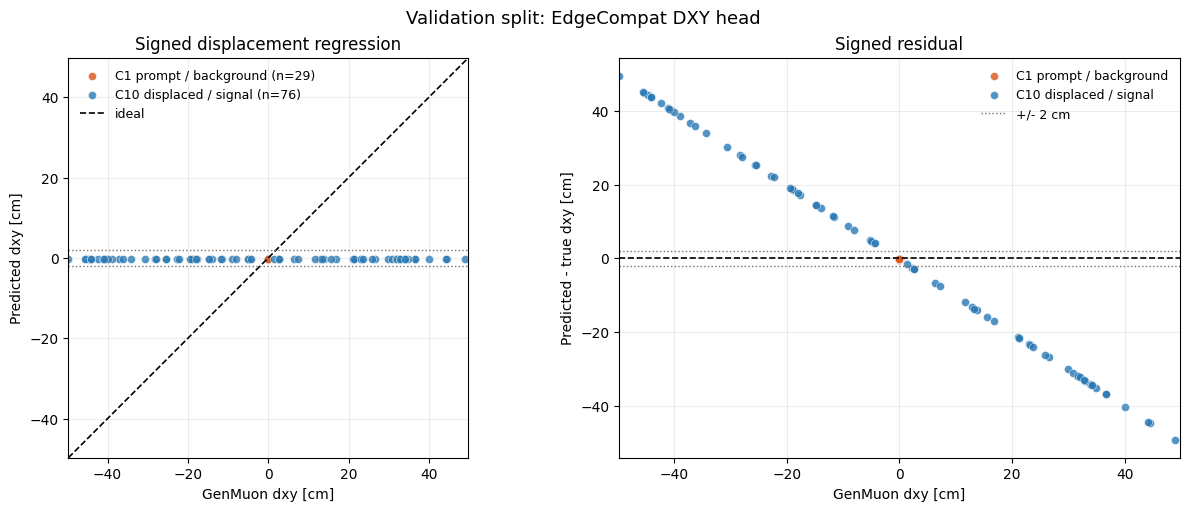

Saved plot: /lhome/ext/uovi156/uovi1561/omtf_gnn_study/build/omtf_gmt/notebook_edge_dxy_smoke/dxy_regression_validation.png
C1_prompt_pt2to5_overlap: n=29, MAE=0.315 cm, bias=-0.315 cm, true range=[-0.04, 0.04] cm, pred range=[-0.40, -0.27] cm
C10_disp_pt20to50_overlap: n=76, MAE=25.492 cm, bias=0.599 cm, true range=[-49.75, 48.88] cm, pred range=[-0.39, -0.26] cm


In [11]:
import matplotlib.pyplot as plt

DXY_PLOT_DATASETS = [
    "C1_prompt_pt2to5_overlap",
    "C10_disp_pt20to50_overlap",
]
DXY_COLORS = {
    "C1_prompt_pt2to5_overlap": "#D95319",
    "C10_disp_pt20to50_overlap": "#2878B5",
}
true_dxy_by_dataset = {}
pred_dxy_by_dataset = {}

model.eval()
with torch.no_grad():
    for name in DXY_PLOT_DATASETS:
        dataset = cached[name]
        n_train = int(0.85 * len(dataset))
        _, validation_subset = torch.utils.data.random_split(
            dataset,
            [n_train, len(dataset) - n_train],
            generator=torch.Generator().manual_seed(42),
        )
        val_indices = list(validation_subset.indices)
        true_chunks = []
        pred_chunks = []
        for start in range(0, len(val_indices), BATCH_SIZE):
            batch_indices = val_indices[start:start + BATCH_SIZE]
            output = model(
                dataset.stubs[batch_indices].to(DEVICE),
                dataset.valid_mask[batch_indices].to(DEVICE),
            )
            occupied = dataset.gen_pt[batch_indices] > 0
            true_chunks.append(dataset.gen_dxy[batch_indices][occupied].cpu())
            pred_chunks.append(output["dxy_pred"].cpu()[occupied])
        true_dxy_by_dataset[name] = torch.cat(true_chunks).numpy()
        pred_dxy_by_dataset[name] = torch.cat(pred_chunks).numpy()

all_true_dxy = np.concatenate(list(true_dxy_by_dataset.values()))
all_pred_dxy = np.concatenate(list(pred_dxy_by_dataset.values()))
plot_limit = max(1.0, float(np.max(np.abs(np.concatenate([all_true_dxy, all_pred_dxy])))))

fig, (ax_scatter, ax_residual) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for name in DXY_PLOT_DATASETS:
    true_values = true_dxy_by_dataset[name]
    pred_values = pred_dxy_by_dataset[name]
    label = "C1 prompt / background" if name == "C1_prompt_pt2to5_overlap" else "C10 displaced / signal"
    ax_scatter.scatter(
        true_values, pred_values, s=34, alpha=0.8,
        color=DXY_COLORS[name], label=f"{label} (n={len(true_values)})",
        edgecolors="white", linewidths=0.4,
    )
    ax_residual.scatter(
        true_values, pred_values - true_values, s=34, alpha=0.8,
        color=DXY_COLORS[name], label=label,
        edgecolors="white", linewidths=0.4,
    )

ax_scatter.plot([-plot_limit, plot_limit], [-plot_limit, plot_limit], "k--", lw=1.2, label="ideal")
ax_scatter.axhline(ML_DXY_THRESHOLD_CM, color="0.45", ls=":", lw=1)
ax_scatter.axhline(-ML_DXY_THRESHOLD_CM, color="0.45", ls=":", lw=1)
ax_scatter.set(xlim=(-plot_limit, plot_limit), ylim=(-plot_limit, plot_limit),
               xlabel="GenMuon dxy [cm]", ylabel="Predicted dxy [cm]",
               title="Signed displacement regression")
ax_scatter.set_aspect("equal", adjustable="box")
ax_scatter.grid(alpha=0.22)
ax_scatter.legend(frameon=False, fontsize=9)

ax_residual.axhline(0.0, color="black", ls="--", lw=1.2)
ax_residual.axhline(ML_DXY_THRESHOLD_CM, color="0.45", ls=":", lw=1,
                    label=f"+/- {ML_DXY_THRESHOLD_CM:g} cm")
ax_residual.axhline(-ML_DXY_THRESHOLD_CM, color="0.45", ls=":", lw=1)
ax_residual.set(xlim=(-plot_limit, plot_limit),
                 xlabel="GenMuon dxy [cm]", ylabel="Predicted - true dxy [cm]",
                 title="Signed residual")
ax_residual.grid(alpha=0.22)
ax_residual.legend(frameon=False, fontsize=9)

fig.suptitle("Validation split: EdgeCompat DXY head", fontsize=13)
DXY_PLOT_PATH = RUN_DIR / "dxy_regression_validation.png"
fig.savefig(DXY_PLOT_PATH, dpi=150)
plt.show()

print(f"Saved plot: {DXY_PLOT_PATH}")
for name in DXY_PLOT_DATASETS:
    residual = pred_dxy_by_dataset[name] - true_dxy_by_dataset[name]
    print(
        f"{name}: n={len(residual)}, "
        f"MAE={np.mean(np.abs(residual)):.3f} cm, "
        f"bias={np.mean(residual):.3f} cm, "
        f"true range=[{true_dxy_by_dataset[name].min():.2f}, {true_dxy_by_dataset[name].max():.2f}] cm, "
        f"pred range=[{pred_dxy_by_dataset[name].min():.2f}, {pred_dxy_by_dataset[name].max():.2f}] cm"
    )

### Baselines y señal disponible
Comparamos `dxy_pred` con el predictor constante cero y con un baseline lineal-oráculo sobre la media de los stubs asignados por `track_id`. Este último usa la asociación verdadera solo para diagnosticar si las features TPS contienen señal; no es una entrada válida para inferencia.

In [13]:
import importlib
import omtf_gmt.dataset as dataset_module

dataset_module = importlib.reload(dataset_module)
oracle_dataset = dataset_module.GMTCachedDataset(
    CACHE_DIR, "C10_disp_pt20to50_overlap"
 )
n_train = int(0.85 * len(oracle_dataset))
train_subset, validation_subset = torch.utils.data.random_split(
    oracle_dataset,
    [n_train, len(oracle_dataset) - n_train],
    generator=torch.Generator().manual_seed(SEED),
 )

def true_stub_mean_rows(indices):
    feature_rows = []
    dxy_targets = []
    for sample_index in indices:
        for slot in range(oracle_dataset.gen_pt.shape[1]):
            if oracle_dataset.gen_pt[sample_index, slot] <= 0:
                continue
            target_id = oracle_dataset.target_track_id[sample_index, slot]
            true_stub_mask = (
                oracle_dataset.valid_mask[sample_index]
                & (oracle_dataset.track_id[sample_index] == target_id)
            )
            if true_stub_mask.any():
                feature_rows.append(
                    oracle_dataset.stubs[sample_index, true_stub_mask].mean(dim=0).numpy()
                )
                dxy_targets.append(float(oracle_dataset.gen_dxy[sample_index, slot]))
    return np.asarray(feature_rows), np.asarray(dxy_targets)

train_features, train_targets = true_stub_mean_rows(train_subset.indices)
val_features, val_targets = true_stub_mean_rows(validation_subset.indices)
train_design = np.column_stack([np.ones(len(train_features)), train_features])
val_design = np.column_stack([np.ones(len(val_features)), val_features])
linear_coefficients, *_ = np.linalg.lstsq(train_design, train_targets, rcond=None)
linear_train_prediction = train_design @ linear_coefficients
linear_val_prediction = val_design @ linear_coefficients
zero_baseline_mae = float(np.mean(np.abs(val_targets)))
model_val_mae = float(np.mean(np.abs(
    pred_dxy_by_dataset["C10_disp_pt20to50_overlap"]
    - true_dxy_by_dataset["C10_disp_pt20to50_overlap"]
 )))
print(f"C10 validation occupied slots: {len(val_targets)}")
print(
    f"Target: mean={val_targets.mean():.3f} cm, std={val_targets.std():.3f} cm, "
    f"range=[{val_targets.min():.2f}, {val_targets.max():.2f}] cm"
 )
print(f"Model dxy MAE: {model_val_mae:.3f} cm")
print(f"Constant-zero baseline MAE: {zero_baseline_mae:.3f} cm")
print(
    f"Oracle true-stub linear MAE: train={np.mean(np.abs(linear_train_prediction - train_targets)):.3f} cm, "
    f"validation={np.mean(np.abs(linear_val_prediction - val_targets)):.3f} cm"
 )

C10 validation occupied slots: 76
Target: mean=-0.916 cm, std=28.766 cm, range=[-49.75, 48.88] cm
Model dxy MAE: 25.492 cm
Constant-zero baseline MAE: 25.493 cm
Oracle true-stub linear MAE: train=25.130 cm, validation=26.363 cm


## 13. Comparar con el OMTF actual según desplazamiento
C10 desplazado es la única señal: mostramos eficiencia por bins de `|GenMuon_dXY|`. C1 prompt y B4 se muestran como aceptación de fondo/control en el split de validación. No aplicamos corte de pT. La selección desplazada ML exige `logit > 0` y `|dxy_pred| >= 2 cm`; C1 sigue siendo un candidato prompt real para el entrenamiento, pero es fondo para esta búsqueda de desplazados.

In [12]:
import awkward as ak

OMTF_ETA_LO_HW = int(0.82 / 0.010875)
OMTF_ETA_HI_HW = int(1.24 / 0.010875)
ML_LOGIT_THRESHOLD = 0.0
ML_DXY_THRESHOLD_CM = 2.0
GEN_DXY_BINS_CM = [(0.0, 2.0), (2.0, 10.0), (10.0, float("inf"))]

model.eval()
validation_event_ids = {}
validation_indices = {}
for name in DATASETS:
    dataset = cached[name]
    n_train = int(0.85 * len(dataset))
    _, val_subset = torch.utils.data.random_split(
        dataset,
        [n_train, len(dataset) - n_train],
        generator=torch.Generator().manual_seed(42),
    )
    indices = list(val_subset.indices)
    validation_indices[name] = indices
    validation_event_ids[name] = {
        int(dataset.meta_event[index]) & 0xFFFFFFFF for index in indices
    }

ml_by_event = {name: {} for name in DATASETS}
with torch.no_grad():
    for name in DATASETS:
        dataset = cached[name]
        indices = validation_indices[name]
        for start in range(0, len(indices), BATCH_SIZE):
            batch_indices = indices[start:start + BATCH_SIZE]
            stubs_batch = dataset.stubs[batch_indices].to(DEVICE)
            mask_batch = dataset.valid_mask[batch_indices].to(DEVICE)
            output = model(stubs_batch, mask_batch)
            fired = output["candidate_logits"] > ML_LOGIT_THRESHOLD
            ml_any = fired.any(dim=1)
            ml_dxy = (fired & (output["dxy_pred"].abs() >= ML_DXY_THRESHOLD_CM)).any(dim=1)
            event_ids = dataset.meta_event[batch_indices].tolist()
            for event_id, fired_any, fired_dxy in zip(
                event_ids, ml_any.tolist(), ml_dxy.tolist()
            ):
                key = int(event_id) & 0xFFFFFFFF
                old_any, old_dxy = ml_by_event[name].get(key, (False, False))
                ml_by_event[name][key] = (old_any or fired_any, old_dxy or fired_dxy)

comparison_rows = []
for name in DATASETS:
    _, nano_path = ROOT_PAIRS[name][0]
    with uproot.open(nano_path) as nano_file:
        tree = nano_file["Events"]
        available = set(tree.keys())
        branches = ["event", "GenMuon_eta", "GenMuon_dXY", "nomtf", "omtf_hwEta"]
        has_eta_st2 = "GenMuon_etaSt2" in available
        if has_eta_st2:
            branches.append("GenMuon_etaSt2")
        arrays = tree.arrays(branches, library="ak")

    is_background = name == "B4" or name.startswith("C1_")
    selected_event_dxy = {}
    omtf_by_event = {}
    for index in range(len(arrays)):
        event_id = int(arrays["event"][index]) & 0xFFFFFFFF
        n_omtf = int(arrays["nomtf"][index])
        omtf_any = False
        if n_omtf > 0:
            hw_eta = np.abs(ak.to_numpy(arrays["omtf_hwEta"][index]).astype(np.float32))
            omtf_any = bool(((hw_eta >= OMTF_ETA_LO_HW) & (hw_eta <= OMTF_ETA_HI_HW)).any())
        omtf_by_event[event_id] = omtf_by_event.get(event_id, False) or omtf_any

        if event_id not in validation_event_ids[name]:
            continue
        if is_background:
            selected_event_dxy[event_id] = None
            continue

        gen_eta = ak.to_numpy(arrays["GenMuon_eta"][index]).astype(np.float32)
        if has_eta_st2:
            eta_st2 = ak.to_numpy(arrays["GenMuon_etaSt2"][index]).astype(np.float32)
            eta_for_filter = np.where(np.abs(eta_st2) > 0.1, eta_st2, gen_eta)
        else:
            eta_for_filter = gen_eta
        gen_dxy = ak.to_numpy(arrays["GenMuon_dXY"][index]).astype(np.float32)
        in_overlap = (np.abs(eta_for_filter) >= 0.82) & (np.abs(eta_for_filter) <= 1.24)
        if in_overlap.any():
            selected_event_dxy[event_id] = float(np.max(np.abs(gen_dxy[in_overlap])))

    if is_background:
        eligible_ids = list(selected_event_dxy)
        assert eligible_ids, f"No hay eventos de validación para {name}"
        n_events = len(eligible_ids)
        ml_any_eff = sum(ml_by_event[name].get(key, (False, False))[0] for key in eligible_ids) / n_events
        ml_dxy_eff = sum(ml_by_event[name].get(key, (False, False))[1] for key in eligible_ids) / n_events
        omtf_eff = sum(omtf_by_event.get(key, False) for key in eligible_ids) / n_events
        background_label = "prompt bg" if name.startswith("C1_") else "noise bg"
        comparison_rows.append((name, background_label, "all", n_events, ml_any_eff, ml_dxy_eff, omtf_eff))
        continue

    for lo, hi in GEN_DXY_BINS_CM:
        eligible_ids = [
            event_id for event_id, abs_dxy in selected_event_dxy.items()
            if abs_dxy is not None and lo <= abs_dxy < hi
        ]
        if not eligible_ids:
            continue
        n_events = len(eligible_ids)
        ml_any_eff = sum(ml_by_event[name].get(key, (False, False))[0] for key in eligible_ids) / n_events
        ml_dxy_eff = sum(ml_by_event[name].get(key, (False, False))[1] for key in eligible_ids) / n_events
        omtf_eff = sum(omtf_by_event.get(key, False) for key in eligible_ids) / n_events
        hi_label = f"{hi:g}" if np.isfinite(hi) else "inf"
        comparison_rows.append((name, f"[{lo:g}, {hi_label})", "efficiency", n_events,
                                ml_any_eff, ml_dxy_eff, omtf_eff))

comparison_columns = [
    ("Dataset", 34, "<"),
    ("Metric / |dxy|", 18, "<"),
    ("N", 7, ">"),
    ("ML any", 10, ">"),
    (f"ML |dxy|>={ML_DXY_THRESHOLD_CM:g}", 15, ">"),
    ("OMTF any", 10, ">"),
]
comparison_border = "+" + "+".join("-" * (width + 2) for _, width, _ in comparison_columns) + "+"


def format_comparison_row(values):
    cells = [
        f" {str(value):{alignment}{width}} "
        for value, (_, width, alignment) in zip(values, comparison_columns)
    ]
    return "|" + "|".join(cells) + "|"


print("Displaced signal: C10; prompt/noise controls: C1 and B4")
print(comparison_border)
print(format_comparison_row([name for name, _, _ in comparison_columns]))
print(comparison_border)
for row in comparison_rows:
    print(format_comparison_row([
        row[0], row[2] if row[1] in {"prompt bg", "noise bg"} else f"{row[1]} cm", row[3],
        f"{row[4]:.1%}", f"{row[5]:.1%}", f"{row[6]:.1%}",
    ]))
print(comparison_border)

Displaced signal: C10; prompt/noise controls: C1 and B4
+------------------------------------+--------------------+---------+------------+-----------------+------------+
| Dataset                            | Metric / |dxy|     |       N |     ML any |     ML |dxy|>=2 |   OMTF any |
+------------------------------------+--------------------+---------+------------+-----------------+------------+
| C1_prompt_pt2to5_overlap           | all                |      11 |       0.0% |            0.0% |      54.5% |
| C10_disp_pt20to50_overlap          | [0, 2) cm          |       2 |       0.0% |            0.0% |     100.0% |
| C10_disp_pt20to50_overlap          | [2, 10) cm         |       3 |       0.0% |            0.0% |     100.0% |
| C10_disp_pt20to50_overlap          | [10, inf) cm       |      18 |       0.0% |            0.0% |     100.0% |
| B4                                 | all                |     190 |       0.0% |            0.0% |      14.7% |
+-------------------------------